# Image Classification: Deteksi Jenis Sampah di Sekitar Kampus

## Deep Learning Using MobileNetV2

### Disusun Oleh

**Nama : Yosua Dirgana Pratama**  
**NIM : 4222301009**


## Deep Learning Using CNN

**Nama:** Yosua Dirgana Pratama

**Dataset:**
https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

### Objective
Membangun model Convolutional Neural Network (CNN) untuk mengklasifikasikan jenis sampah berdasarkan gambar sehingga dapat membantu proses pemilahan sampah di lingkungan kampus.

## Import Libraries

In [3]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Membaca Dataset

In [4]:
dataset_path = "TrashType_Image_Dataset"

classes = sorted(os.listdir(dataset_path))

print("Kategori Sampah:")
print(classes)

Kategori Sampah:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Jumlah Data Tiap Kelas

In [5]:
class_count = {}

for cls in classes:
    
    folder = os.path.join(
        dataset_path,
        cls
    )
    
    class_count[cls] = len(
        os.listdir(folder)
    )

df_count = pd.DataFrame(
    class_count.items(),
    columns=["Class","Total"]
)

df_count

,Class,Total
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


## Grafik Distribusi Dataset

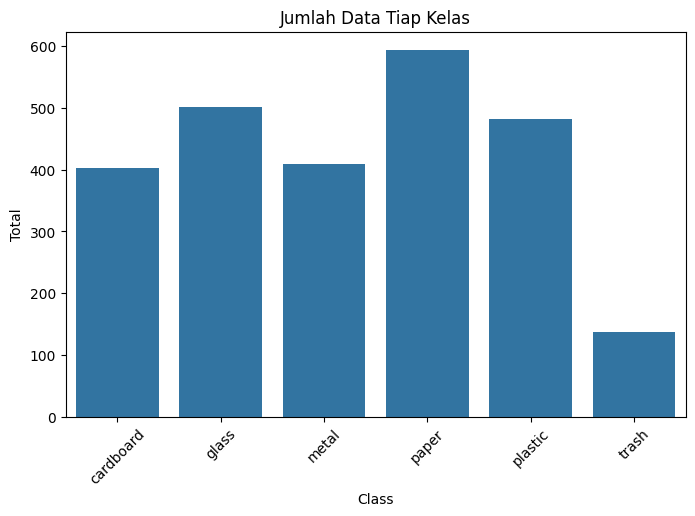

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_count,
    x="Class",
    y="Total"
)

plt.title(
    "Jumlah Data Tiap Kelas"
)

plt.xticks(rotation=45)

plt.show()

## Persentase Data Tiap Kelas

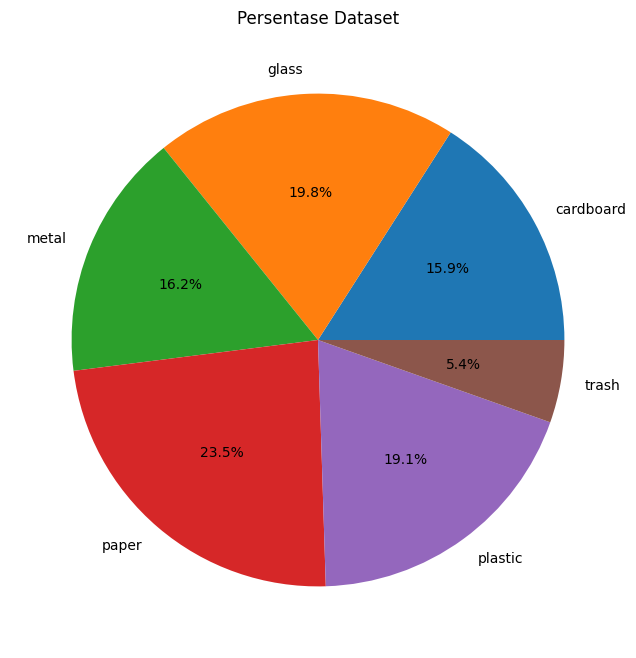

In [7]:
plt.figure(figsize=(8,8))

plt.pie(
    df_count["Total"],
    labels=df_count["Class"],
    autopct="%1.1f%%"
)

plt.title(
    "Persentase Dataset"
)

plt.show()

## Menampilkan Contoh Gambar

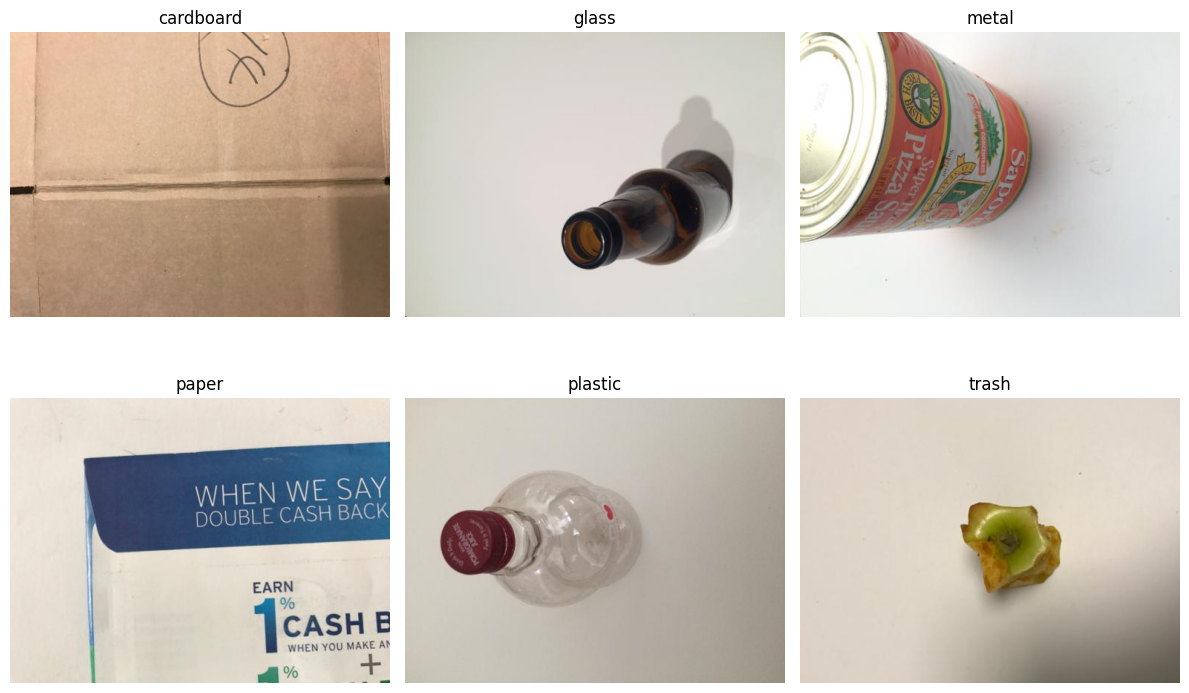

In [8]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    folder = os.path.join(
        dataset_path,
        cls
    )

    img_name = os.listdir(folder)[0]

    img_path = os.path.join(
        folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(
        2,
        3,
        i+1
    )

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Preprocessing Data

In [9]:
data = []
labels = []

IMG_SIZE = 64

for label, cls in enumerate(classes):

    folder = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(folder):

        try:

            img_path = os.path.join(
                folder,
                img_name
            )

            img = cv2.imread(img_path)

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            data.append(
                img.flatten()
            )

            labels.append(
                label
            )

        except:
            pass

X = np.array(data)

y = np.array(labels)

print(X.shape)

print(y.shape)

(2527, 12288)
(2527,)


## Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (2021, 12288)
Testing: (506, 12288)


## Training Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Prediksi Data Testing

In [12]:
y_pred = rf.predict(
    X_test
)

## Accuracy Model

In [13]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        acc*100,
        2
    ),
    "%"
)

Accuracy: 68.97 %


## Classification Report

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

   cardboard       0.74      0.69      0.71        81
       glass       0.61      0.67      0.64       100
       metal       0.69      0.57      0.63        82
       paper       0.71      0.84      0.77       119
     plastic       0.68      0.67      0.68        97
       trash       0.88      0.52      0.65        27

    accuracy                           0.69       506
   macro avg       0.72      0.66      0.68       506
weighted avg       0.69      0.69      0.69       506



## Confusion Matrix

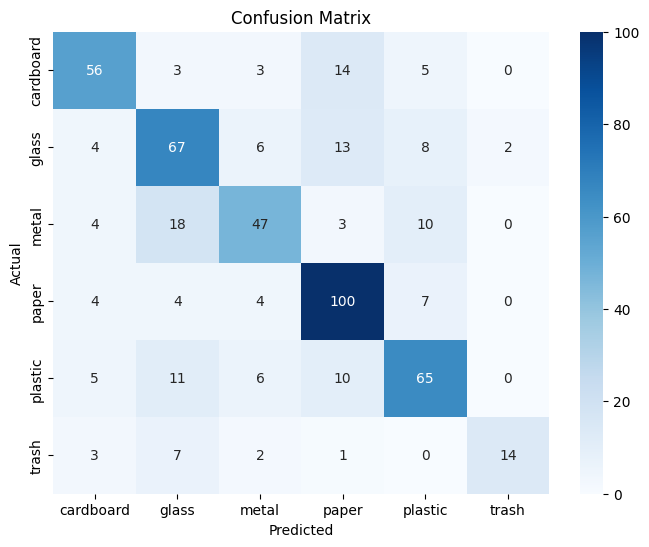

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

## Distribusi Hasil Prediksi

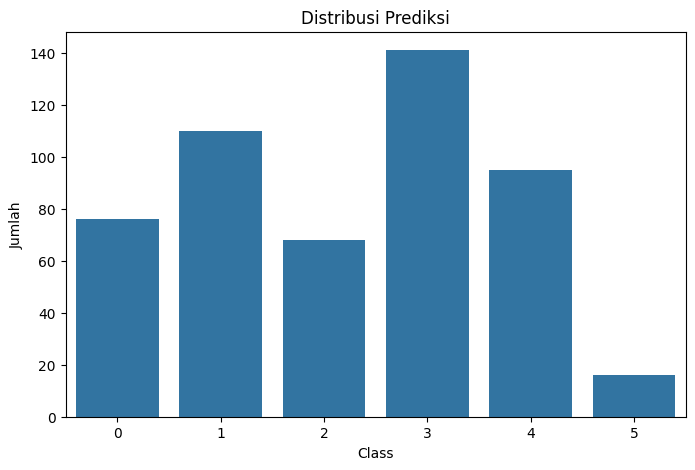

In [16]:
pred_count = pd.Series(
    y_pred
).value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=pred_count.index,
    y=pred_count.values
)

plt.title(
    "Distribusi Prediksi"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Jumlah"
)

plt.show()

## Menampilkan Hasil Prediksi

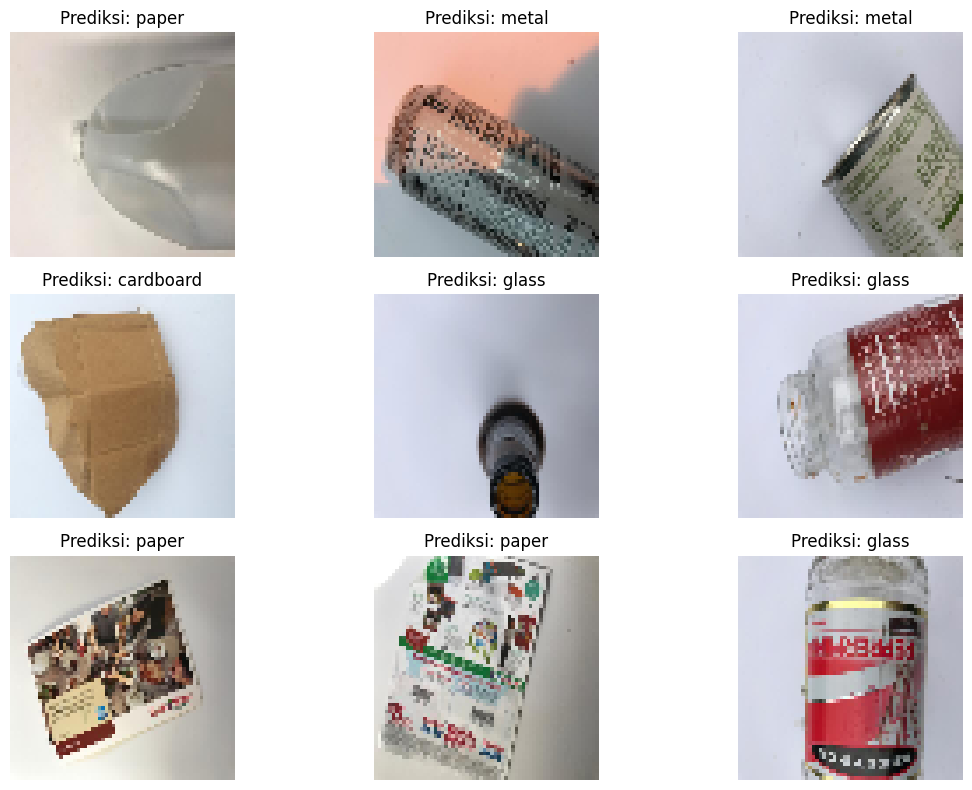

In [17]:
plt.figure(figsize=(12,8))

for i in range(9):

    img = X_test[i].reshape(
        64,
        64,
        3
    )

    pred = rf.predict(
        [X_test[i]]
    )[0]

    plt.subplot(
        3,
        3,
        i+1
    )

    plt.imshow(img)

    plt.title(
        f"Prediksi: {classes[pred]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Analisis

1. Dataset terdiri dari 6 kategori sampah.
2. Kelas paper memiliki jumlah data terbanyak.
3. Kelas trash memiliki jumlah data paling sedikit.
4. Random Forest mampu mempelajari pola visual dari gambar sampah.
5. Kesalahan klasifikasi umumnya terjadi pada kelas yang memiliki karakteristik visual mirip seperti paper dan cardboard.
6. Model menghasilkan performa yang cukup baik untuk klasifikasi gambar sederhana.

## Kesimpulan

Pada proyek ini telah dibangun model klasifikasi gambar menggunakan algoritma Random Forest untuk mendeteksi jenis sampah.

Model berhasil mengklasifikasikan gambar ke dalam kategori:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

Berdasarkan hasil evaluasi, model menunjukkan performa yang cukup baik dalam mengenali berbagai jenis sampah dan dapat digunakan sebagai dasar sistem pemilahan sampah otomatis di lingkungan kampus.

Untuk penelitian selanjutnya dapat digunakan metode Deep Learning seperti CNN untuk memperoleh akurasi yang lebih tinggi.